EMOTION RECOGNITION FROM SPEECH USING MFCC AND CNN

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

path = '/content/drive/MyDrive/Emotion_Recognition'

print(os.listdir(path))

path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS'

print(os.listdir(path))

['Colab Notebooks', 'Credit_Scoring', 'Disease_Prediction', 'Emotion_Recognition']
['RAVDESS']
['speech.zip', 'speech']


In [ ]:
import os

base_path = '/content/drive/MyDrive/Emotion_Recognition'

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower() == 'speech.zip':
            print("✅ File found:")
            print(os.path.join(root, file))

✅ File found:
/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech.zip


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech.zip'

extract_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [ ]:
import os

path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech'

print(os.listdir(path)[:20])

['Crema', 'Ravdess', 'Savee', 'Tess']


In [ ]:
import os

ravdess_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess'

print(os.listdir(ravdess_path)[:20])

['audio_speech_actors_01-24']


In [ ]:
import os

ravdess_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24'

print(os.listdir(ravdess_path)[:30])

['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']


In [ ]:
import os

ravdess_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24'

total_files = 0

for root, dirs, files in os.walk(ravdess_path):
    for file in files:
        if file.lower().endswith('.wav'):
            total_files += 1

print("Total Audio Files:", total_files)

Total Audio Files: 1440


In [ ]:
import os

for root, dirs, files in os.walk(ravdess_path):
    for file in files:
        if file.lower().endswith('.wav'):
            print("First Audio File:")
            print(os.path.join(root, file))
            break
    else:
        continue
    break

First Audio File:
/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24/Actor_01/03-01-01-01-01-01-01.wav


In [ ]:
import os

file_name = '03-01-01-01-01-01-01.wav'

# Filename ko "-" ke according split karna
parts = file_name.replace('.wav', '').split('-')

# Third value emotion code hai
emotion_code = int(parts[2])

emotion_labels = {
    1: 'Neutral',
    2: 'Calm',
    3: 'Happy',
    4: 'Sad',
    5: 'Angry',
    6: 'Fearful',
    7: 'Disgust',
    8: 'Surprised'
}

emotion = emotion_labels[emotion_code]

print("File Name:", file_name)
print("Emotion Code:", emotion_code)
print("Emotion:", emotion)

File Name: 03-01-01-01-01-01-01.wav
Emotion Code: 1
Emotion: Neutral


In [ ]:
import librosa

audio_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24/Actor_01/03-01-01-01-01-01-01.wav'

audio, sample_rate = librosa.load(audio_path, sr=None)

print("Audio loaded successfully!")
print("Sample Rate:", sample_rate)
print("Audio Duration:", len(audio) / sample_rate, "seconds")
print("Audio Shape:", audio.shape)

Audio loaded successfully!
Sample Rate: 48000
Audio Duration: 3.3032916666666665 seconds
Audio Shape: (158558,)


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Audio path
audio_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24/Actor_01/03-01-01-01-01-01-01.wav'

# Load audio
audio, sample_rate = librosa.load(audio_path, sr=None)

# Extract 40 MFCC features
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

print("MFCC extracted successfully!")
print("MFCC Shape:", mfcc.shape)

MFCC extracted successfully!
MFCC Shape: (40, 310)


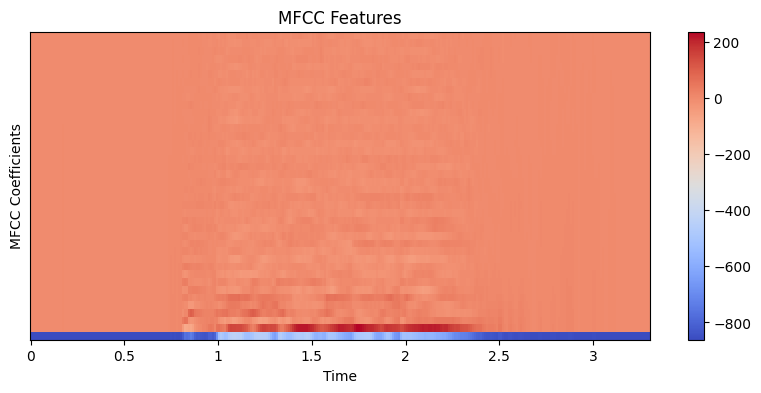

In [ ]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mfcc,
    x_axis='time',
    sr=sample_rate
)

plt.colorbar()
plt.title('MFCC Features')
plt.xlabel('Time')
plt.ylabel('MFCC Coefficients')
plt.show()

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24'

print("Dataset path:")
print(dataset_path)

print("\nNumber of actors:", len(os.listdir(dataset_path)))

Dataset path:
/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24

Number of actors: 24


In [ ]:
import os
import librosa
import numpy as np

# Dataset path
dataset_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24'

# Emotion mapping
emotion_labels = {
    1: 'neutral',
    2: 'calm',
    3: 'happy',
    4: 'sad',
    5: 'angry',
    6: 'fearful',
    7: 'disgust',
    8: 'surprised'
}

X = []
y = []

# Go through all actor folders
for actor in sorted(os.listdir(dataset_path)):

    actor_path = os.path.join(dataset_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):

        if file.lower().endswith('.wav'):

            # Extract emotion code from filename
            parts = file.replace('.wav', '').split('-')
            emotion_code = int(parts[2])

            # Get emotion name
            emotion = emotion_labels[emotion_code]

            # Full audio path
            audio_path = os.path.join(actor_path, file)

            # Load audio
            audio, sr = librosa.load(audio_path, sr=22050)

            # Extract 40 MFCCs
            mfcc = librosa.feature.mfcc(
                y=audio,
                sr=sr,
                n_mfcc=40
            )

            # Fixed size: 40 x 200
            if mfcc.shape[1] < 200:
                pad_width = 200 - mfcc.shape[1]
                mfcc = np.pad(
                    mfcc,
                    pad_width=((0, 0), (0, pad_width)),
                    mode='constant'
                )
            else:
                mfcc = mfcc[:, :200]

            X.append(mfcc)
            y.append(emotion)

print("MFCC extraction completed!")
print("Total samples:", len(X))
print("Feature shape of first sample:", X[0].shape)
print("Total labels:", len(y))

MFCC extraction completed!
Total samples: 1440
Feature shape of first sample: (40, 200)
Total labels: 1440


In [ ]:
import numpy as np
from collections import Counter

# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nEmotion Distribution:")
emotion_counts = Counter(y)

for emotion, count in sorted(emotion_counts.items()):
    print(f"{emotion}: {count}")

X Shape: (1440, 40, 200)
y Shape: (1440,)

Emotion Distribution:
angry: 192
calm: 192
disgust: 192
fearful: 192
happy: 192
neutral: 96
sad: 192
surprised: 192


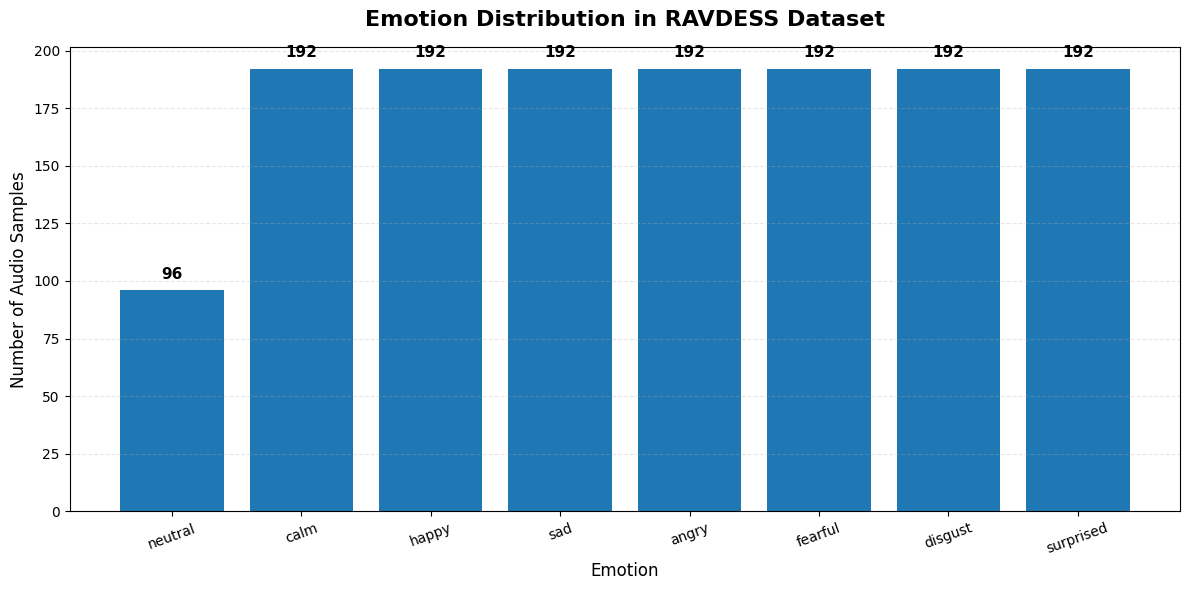

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Count each emotion
emotion_counts = Counter(y)

# Emotion names
emotions = [
    'neutral',
    'calm',
    'happy',
    'sad',
    'angry',
    'fearful',
    'disgust',
    'surprised'
]

# Get counts in correct order
counts = [emotion_counts[emotion] for emotion in emotions]

# Create figure
plt.figure(figsize=(12, 6))

bars = plt.bar(emotions, counts)

# Add values above bars
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Title and labels
plt.title(
    'Emotion Distribution in RAVDESS Dataset',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Audio Samples', fontsize=12)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Keep graph clean
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder
label_encoder = LabelEncoder()

# Convert emotion names into numbers
y_encoded = label_encoder.fit_transform(y)

# Display mapping
print("Emotion Label Mapping:")

for number, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion} -> {number}")

# Check encoded labels
print("\nEncoded Labels:")
print(y_encoded[:20])

print("\nX Shape:", X.shape)
print("y_encoded Shape:", y_encoded.shape)

Emotion Label Mapping:
angry -> 0
calm -> 1
disgust -> 2
fearful -> 3
happy -> 4
neutral -> 5
sad -> 6
surprised -> 7

Encoded Labels:
[5 5 5 5 1 1 1 1 1 1 1 1 4 4 4 4 4 4 4 4]

X Shape: (1440, 40, 200)
y_encoded Shape: (1440,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training Data:
X_train: (1152, 40, 200)
y_train: (1152,)

Testing Data:
X_test: (288, 40, 200)
y_test: (288,)


In [ ]:
# Add channel dimension for CNN
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print("CNN Training Shape:", X_train_cnn.shape)
print("CNN Testing Shape:", X_test_cnn.shape)

CNN Training Shape: (1152, 40, 200, 1)
CNN Testing Shape: (288, 40, 200, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

# Create CNN model
model = Sequential([

    # Input + First Convolution
    Conv2D(
        32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(40, 200, 1)
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolution
    Conv2D(
        64,
        kernel_size=(3, 3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Third Convolution
    Conv2D(
        128,
        kernel_size=(3, 3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Convert feature maps into 1D
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output layer: 8 emotions
    Dense(8, activation='softmax')
])

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 198, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 198, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 48, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 46, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 46, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 23, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8832)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,130,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,225,224 (4.67 MB)

 Trainable params: 1,224,776 (4.67 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    Input(shape=(40, 200, 1)),

    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(8, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 38, 198, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 38, 198, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 19, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 17, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 17, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 48, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 46, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 46, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 23, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8832)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,130,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,225,224 (4.67 MB)

 Trainable params: 1,224,776 (4.67 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Train the CNN model

history = model.fit(
    X_train_cnn,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

print("Model training completed!")

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 677ms/step - accuracy: 0.1868 - loss: 3.0258 - val_accuracy: 0.1991 - val_loss: 1.9894
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 769ms/step - accuracy: 0.1781 - loss: 1.9973 - val_accuracy: 0.1775 - val_loss: 2.0421
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 705ms/step - accuracy: 0.2085 - loss: 1.9876 - val_accuracy: 0.2078 - val_loss: 1.9710
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 898ms/step - accuracy: 0.1911 - loss: 1.9526 - val_accuracy: 0.2641 - val_loss: 1.8425
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 661ms/step - accuracy: 0.2313 - loss: 1.8777 - val_accuracy: 0.2381 - val_loss: 1.8497
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 644ms/step - accuracy: 0.2465 - loss: 1.8224 - val_accuracy: 0.2381 - val_loss: 1.8135
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 771ms/step - accuracy: 0.2562 - loss: 1.8319 - val_accuracy: 0.2381 - val_loss: 1.8477
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 684ms/step - accuracy: 0.2389 - loss: 1.8452 - val_accu

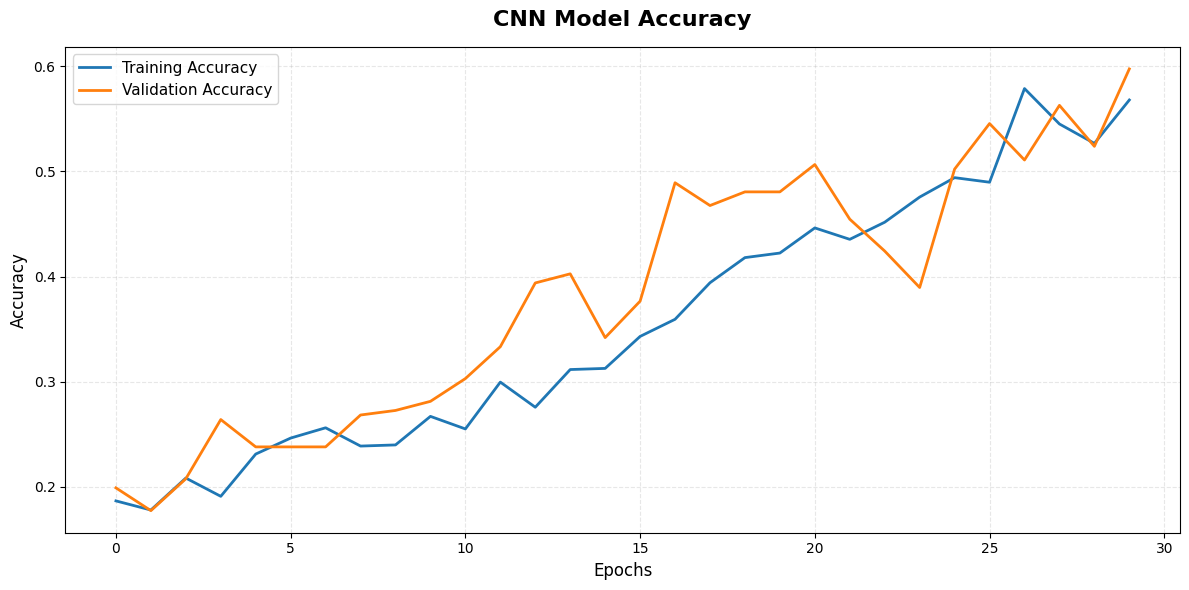

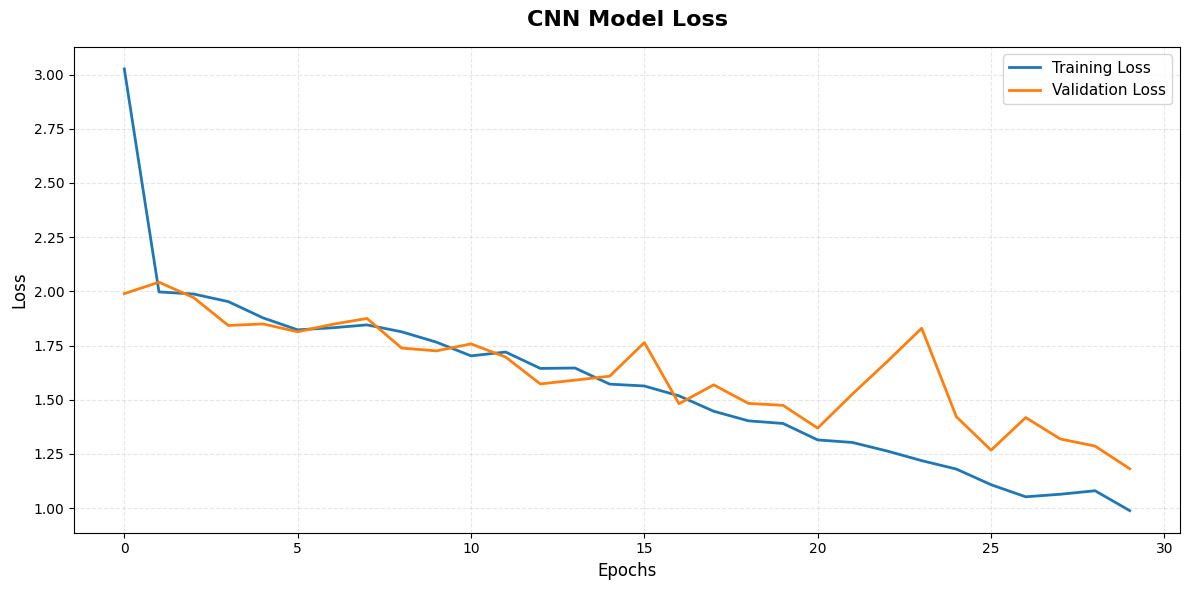

In [ ]:
import matplotlib.pyplot as plt

# =========================
# Accuracy Graph
# =========================

plt.figure(figsize=(12, 6))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title(
    'CNN Model Accuracy',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


# =========================
# Loss Graph
# =========================

plt.figure(figsize=(12, 6))

plt.plot(
    history.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title(
    'CNN Model Loss',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the trained CNN model on test data

test_loss, test_accuracy = model.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print("\n====================================")
print("       MODEL TEST RESULTS")
print("====================================")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print("====================================")

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 332ms/step - accuracy: 0.5278 - loss: 1.4498

       MODEL TEST RESULTS
Test Loss     : 1.4498
Test Accuracy : 52.78%


Confusion Matrix:
[[25  1  4  0  6  0  2  0]
 [ 0 29  2  0  1  2  4  0]
 [ 6  6 20  0  1  0  3  2]
 [ 1  2  2 23  8  1  1  1]
 [ 4  0  1  8 17  2  2  5]
 [ 0  7  0  1  0  8  3  0]
 [ 1 13  6  7  2  1  8  0]
 [ 0  1  1  2 11  1  1 22]]


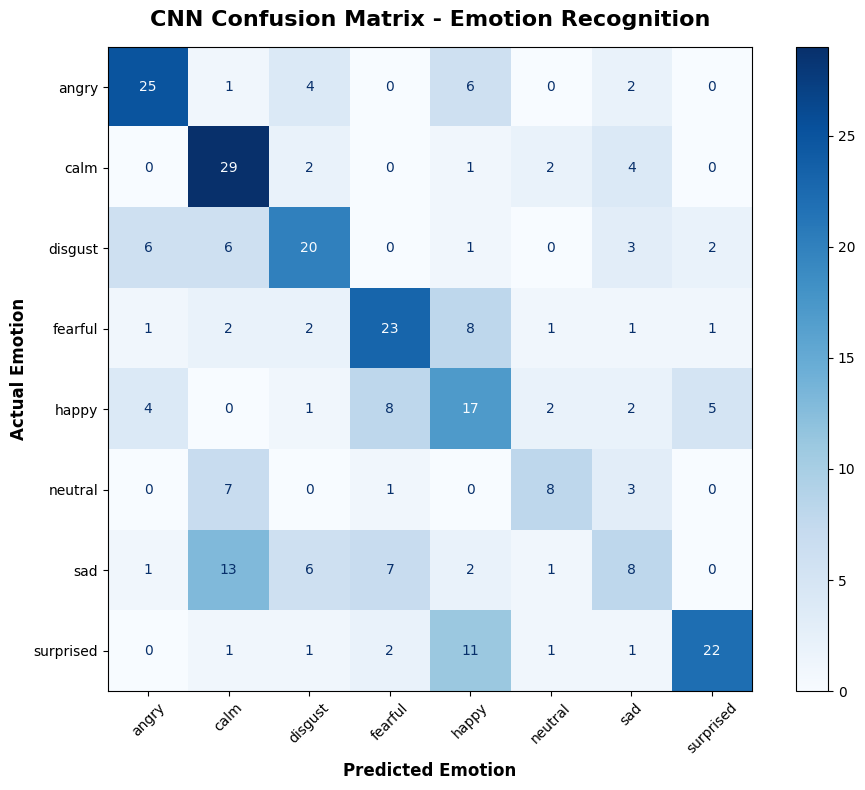

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
y_pred_prob = model.predict(X_test_cnn, verbose=0)

# Convert probabilities to class numbers
y_pred = np.argmax(y_pred_prob, axis=1)

# Get class names
class_names = label_encoder.classes_

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Create display
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format='d',
    xticks_rotation=45,
    colorbar=True
)

ax.set_title(
    'CNN Confusion Matrix - Emotion Recognition',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Predicted Emotion',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Actual Emotion',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4
)

print("==============================================")
print("       CLASSIFICATION REPORT")
print("==============================================")
print(report)

       CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry     0.6757    0.6579    0.6667        38
        calm     0.4915    0.7632    0.5979        38
     disgust     0.5556    0.5263    0.5405        38
     fearful     0.5610    0.5897    0.5750        39
       happy     0.3696    0.4359    0.4000        39
     neutral     0.5333    0.4211    0.4706        19
         sad     0.3333    0.2105    0.2581        38
   surprised     0.7333    0.5641    0.6377        39

    accuracy                         0.5278       288
   macro avg     0.5317    0.5211    0.5183       288
weighted avg     0.5318    0.5278    0.5217       288



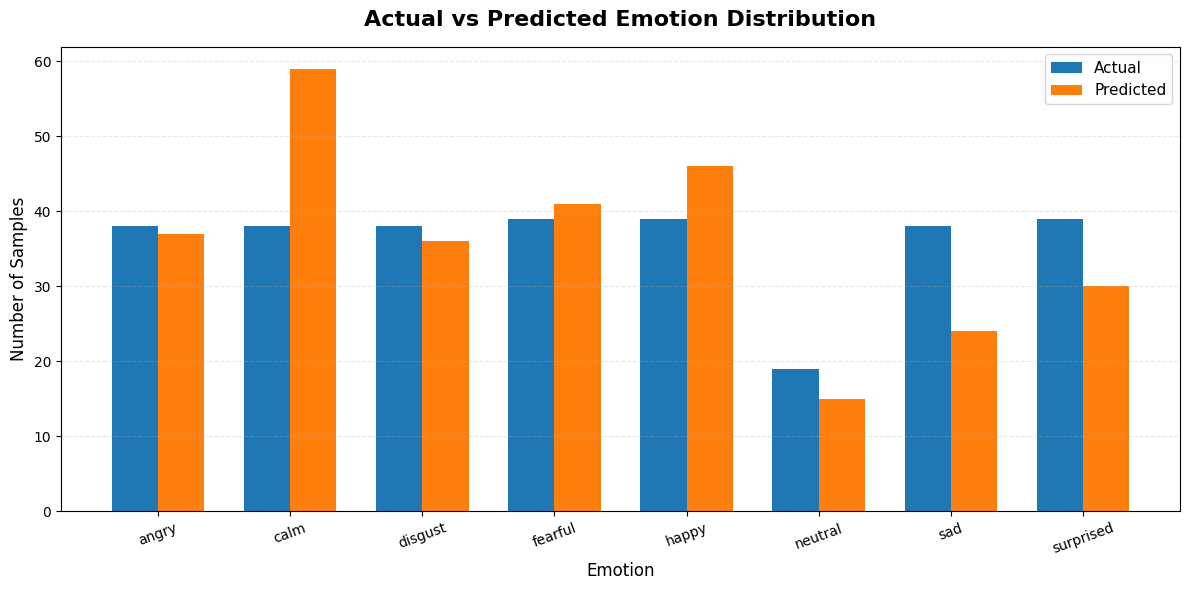

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Count actual and predicted emotions
actual_counts = Counter(y_test)
predicted_counts = Counter(y_pred)

# Emotion names
emotions = list(class_names)

# Get counts
actual_values = [actual_counts[i] for i in range(len(emotions))]
predicted_values = [predicted_counts[i] for i in range(len(emotions))]

# Position of bars
x = np.arange(len(emotions))
width = 0.35

# Create graph
plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    actual_values,
    width,
    label='Actual'
)

plt.bar(
    x + width/2,
    predicted_values,
    width,
    label='Predicted'
)

# Title
plt.title(
    'Actual vs Predicted Emotion Distribution',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

plt.xticks(
    x,
    emotions,
    rotation=20
)

plt.legend(fontsize=11)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
new_audio_path = '/content/drive/MyDrive/Emotion_Recognition/test_audio.wav'

print("Audio file:")
print(new_audio_path)

Audio file:
/content/drive/MyDrive/Emotion_Recognition/test_audio.wav


In [ ]:
import os

# RAVDESS dataset path
dataset_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24'

# Select one audio file
test_actor = 'Actor_01'
actor_path = os.path.join(dataset_path, test_actor)

audio_files = [
    f for f in os.listdir(actor_path)
    if f.lower().endswith('.wav')
]

# Select first audio file
new_audio_path = os.path.join(actor_path, audio_files[0])

print("Selected Audio:")
print(new_audio_path)

Selected Audio:
/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24/Actor_01/03-01-01-01-01-01-01.wav


In [ ]:
import librosa
import numpy as np

# Load audio
audio, sr = librosa.load(
    new_audio_path,
    sr=22050
)

# Extract MFCC
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

# Make shape exactly (40, 200)
if mfcc.shape[1] < 200:
    pad_width = 200 - mfcc.shape[1]

    mfcc = np.pad(
        mfcc,
        pad_width=((0, 0), (0, pad_width)),
        mode='constant'
    )
else:
    mfcc = mfcc[:, :200]

# Add batch and channel dimensions
mfcc_input = mfcc[np.newaxis, ..., np.newaxis]

print("MFCC Shape:", mfcc.shape)
print("CNN Input Shape:", mfcc_input.shape)

# Prediction
prediction = model.predict(
    mfcc_input,
    verbose=0
)

# Get predicted class
predicted_class = np.argmax(prediction[0])

# Convert number to emotion
predicted_emotion = label_encoder.inverse_transform(
    [predicted_class]
)[0]

# Confidence
confidence = prediction[0][predicted_class] * 100

print("\n====================================")
print("       EMOTION PREDICTION")
print("====================================")
print("Predicted Emotion :", predicted_emotion)
print(f"Confidence        : {confidence:.2f}%")
print("====================================")

MFCC Shape: (40, 200)
CNN Input Shape: (1, 40, 200, 1)

       EMOTION PREDICTION
Predicted Emotion : sad
Confidence        : 23.66%


In [ ]:
# Extract actual emotion from filename
file_name = os.path.basename(new_audio_path)

parts = file_name.replace('.wav', '').split('-')
actual_code = int(parts[2])

emotion_labels = {
    1: 'neutral',
    2: 'calm',
    3: 'happy',
    4: 'sad',
    5: 'angry',
    6: 'fearful',
    7: 'disgust',
    8: 'surprised'
}

actual_emotion = emotion_labels[actual_code]

print("\nActual Emotion    :", actual_emotion)
print("Predicted Emotion :", predicted_emotion)

if actual_emotion == predicted_emotion:
    print("Result            :  Correct Prediction")
else:
    print("Result            : Incorrect Prediction")


Actual Emotion    : neutral
Predicted Emotion : sad
Result            : Incorrect Prediction


In [ ]:
# Calculate mean and standard deviation from training data

mean = np.mean(X_train_cnn)
std = np.std(X_train_cnn)

# Normalize training data
X_train_norm = (X_train_cnn - mean) / (std + 1e-8)

# Normalize test data using training statistics
X_test_norm = (X_test_cnn - mean) / (std + 1e-8)

print("Normalization completed!")

print("Training Mean:", np.mean(X_train_norm))
print("Training Std:", np.std(X_train_norm))

print("X_train_norm Shape:", X_train_norm.shape)
print("X_test_norm Shape:", X_test_norm.shape)

Normalization completed!
Training Mean: 5.0339434e-08
Training Std: 1.0000002
X_train_norm Shape: (1152, 40, 200, 1)
X_test_norm Shape: (288, 40, 200, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

# Improved CNN model
improved_model = Sequential([

    # Input
    Input(shape=(40, 200, 1)),

    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.20),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    # Reduce feature maps
    GlobalAveragePooling2D(),

    # Fully connected layer
    Dense(128, activation='relu'),
    Dropout(0.40),

    # 8 emotion classes
    Dense(8, activation='softmax')
])

# Display architecture
improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 40, 200, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 40, 200, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 100, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 100, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 100, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 20, 100, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 10, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 10, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 25, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 25, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,112 (434.03 KB)

 Trainable params: 110,664 (432.28 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Improved CNN compiled successfully!")

Improved CNN compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Train improved CNN
history_improved = improved_model.fit(
    X_train_norm,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print(" Improved CNN training completed!")

Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 796ms/step - accuracy: 0.1933 - loss: 2.0192 - val_accuracy: 0.1299 - val_loss: 2.0631 - learning_rate: 0.0010
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 793ms/step - accuracy: 0.2769 - loss: 1.8553 - val_accuracy: 0.1299 - val_loss: 2.1309 - learning_rate: 0.0010
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 788ms/step - accuracy: 0.2899 - loss: 1.7757 - val_accuracy: 0.1169 - val_loss: 2.3757 - learning_rate: 0.0010
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3679 - loss: 1.6772
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
29/29 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.3388 - loss: 1.7012 - val_accuracy: 0.1429 - val_loss: 2.8159 - learning_rate: 0.0010
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 794ms/step - accuracy: 0.3681 - loss: 1.6230 - val_accuracy: 0.1255 - val_loss: 3.2119 - learning_rate: 5.0000e-04
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 789ms/step - accuracy: 0.3952 - loss: 1.5888

In [ ]:
# Evaluate improved CNN on test data

improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    X_test_norm,
    y_test,
    verbose=1
)

print("\n======================================")
print("     IMPROVED CNN TEST RESULTS")
print("======================================")
print(f"Test Loss     : {improved_test_loss:.4f}")
print(f"Test Accuracy : {improved_test_accuracy * 100:.2f}%")
print("======================================")

# Compare with baseline model
print("\n========== MODEL COMPARISON ==========")
print(f"Baseline CNN Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Improved CNN Accuracy  : {improved_test_accuracy * 100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 301ms/step - accuracy: 0.1562 - loss: 2.0574

     IMPROVED CNN TEST RESULTS
Test Loss     : 2.0574
Test Accuracy : 15.62%

========== MODEL COMPARISON ==========
Baseline CNN Accuracy  : 52.78%
Improved CNN Accuracy  : 15.62%


In [ ]:
# Check baseline model performance again

baseline_loss, baseline_accuracy = model.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print("\n====================================")
print("       BASELINE CNN RESULTS")
print("====================================")
print(f"Test Loss     : {baseline_loss:.4f}")
print(f"Test Accuracy : {baseline_accuracy * 100:.2f}%")
print("====================================")

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 374ms/step - accuracy: 0.5278 - loss: 1.4498

       BASELINE CNN RESULTS
Test Loss     : 1.4498
Test Accuracy : 52.78%


In [ ]:
# Save the baseline CNN model

model.save(
    '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/emotion_cnn_baseline.keras'
)

print("Baseline CNN model saved successfully!")

Baseline CNN model saved successfully!


In [ ]:
import joblib

# Save label encoder
joblib.dump(
    label_encoder,
    '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/label_encoder.pkl'
)

print("Label encoder saved successfully!")

Label encoder saved successfully!


In [ ]:
import librosa
import numpy as np

def augment_audio(audio, sr):
    """
    Create an augmented version of an audio signal.
    """

    # Randomly choose augmentation
    choice = np.random.choice([
        'noise',
        'shift',
        'volume'
    ])

    if choice == 'noise':
        # Add small Gaussian noise
        noise = np.random.randn(len(audio))
        audio_aug = audio + 0.005 * noise

    elif choice == 'shift':
        # Shift audio slightly in time
        shift = np.random.randint(
            int(-0.2 * sr),
            int(0.2 * sr)
        )

        audio_aug = np.roll(audio, shift)

    else:
        # Random volume change
        factor = np.random.uniform(0.8, 1.2)
        audio_aug = audio * factor

    # Prevent clipping
    audio_aug = np.clip(audio_aug, -1.0, 1.0)

    return audio_aug

In [ ]:
# Select one original audio file
sample_audio_path = new_audio_path

# Load audio
audio, sr = librosa.load(
    sample_audio_path,
    sr=22050
)

# Create augmented audio
augmented_audio = augment_audio(audio, sr)

print("Original Audio Shape :", audio.shape)
print("Augmented Audio Shape:", augmented_audio.shape)
print("Sample Rate          :", sr)
print("Audio augmentation working!")

Original Audio Shape : (72838,)
Augmented Audio Shape: (72838,)
Sample Rate          : 22050
Audio augmentation working!


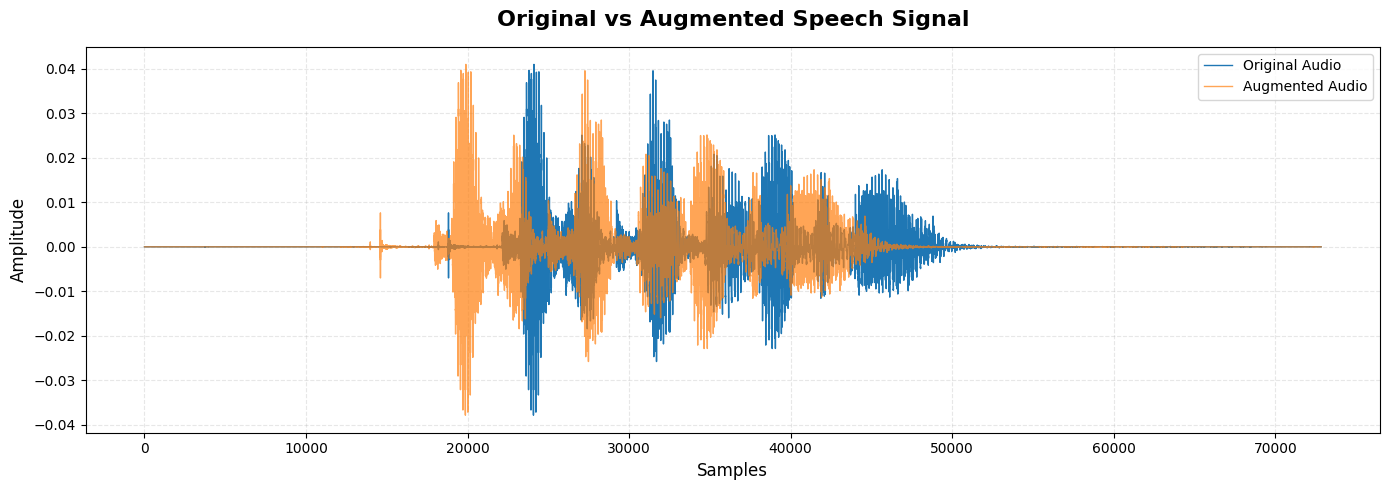

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    audio,
    linewidth=1,
    label='Original Audio'
)

plt.plot(
    augmented_audio,
    linewidth=1,
    alpha=0.7,
    label='Augmented Audio'
)

plt.title(
    'Original vs Augmented Speech Signal',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Samples', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import os
import librosa
import numpy as np

# RAVDESS dataset path
dataset_path = '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24'

# Store original + augmented features
X_augmented = []
y_augmented = []

# Emotion mapping
emotion_labels = {
    1: 'neutral',
    2: 'calm',
    3: 'happy',
    4: 'sad',
    5: 'angry',
    6: 'fearful',
    7: 'disgust',
    8: 'surprised'
}

# Process all audio files
for actor in sorted(os.listdir(dataset_path)):

    actor_path = os.path.join(dataset_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file_name in os.listdir(actor_path):

        if not file_name.lower().endswith('.wav'):
            continue

        # Load audio
        file_path = os.path.join(actor_path, file_name)

        audio, sr = librosa.load(
            file_path,
            sr=22050
        )

        # Extract emotion code
        emotion_code = int(file_name.split('-')[2])

        # Keep only valid emotion classes
        if emotion_code not in emotion_labels:
            continue

        # -----------------------------
        # Original MFCC
        # -----------------------------
        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=40
        )

        # Make exactly 200 time frames
        if mfcc.shape[1] < 200:

            pad_width = 200 - mfcc.shape[1]

            mfcc = np.pad(
                mfcc,
                ((0, 0), (0, pad_width)),
                mode='constant'
            )

        else:
            mfcc = mfcc[:, :200]

        X_augmented.append(mfcc)
        y_augmented.append(emotion_code - 1)

        # -----------------------------
        # Augmented Audio MFCC
        # -----------------------------
        augmented_audio = augment_audio(
            audio,
            sr
        )

        augmented_mfcc = librosa.feature.mfcc(
            y=augmented_audio,
            sr=sr,
            n_mfcc=40
        )

        # Make exactly 200 time frames
        if augmented_mfcc.shape[1] < 200:

            pad_width = 200 - augmented_mfcc.shape[1]

            augmented_mfcc = np.pad(
                augmented_mfcc,
                ((0, 0), (0, pad_width)),
                mode='constant'
            )

        else:
            augmented_mfcc = augmented_mfcc[:, :200]

        X_augmented.append(augmented_mfcc)
        y_augmented.append(emotion_code - 1)


# Convert to NumPy arrays
X_augmented = np.array(X_augmented)
y_augmented = np.array(y_augmented)

print("========================================")
print("     AUGMENTED DATASET CREATED")
print("========================================")

print("Total Samples :", len(X_augmented))
print("Feature Shape :", X_augmented.shape)
print("Labels Shape  :", y_augmented.shape)

     AUGMENTED DATASET CREATED
Total Samples : 2880
Feature Shape : (2880, 40, 200)
Labels Shape  : (2880,)


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Original data
X_original = X_augmented[:1440]
y_original = y_augmented[:1440]

# Augmented data
X_aug = X_augmented[1440:]
y_aug = y_augmented[1440:]

# Split ORIGINAL data
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_original,
    y_original,
    test_size=0.20,
    random_state=42,
    stratify=y_original
)

print("Original Training Shape :", X_train_orig.shape)
print("Original Testing Shape  :", X_test_orig.shape)

# Find the same training samples in augmented dataset
# We use the same random split indices
train_indices, test_indices = train_test_split(
    np.arange(1440),
    test_size=0.20,
    random_state=42,
    stratify=y_original
)

# Select augmented versions corresponding to training samples
X_train_aug = X_aug[train_indices]
y_train_aug = y_aug[train_indices]

# Combine original training + augmented training
X_train_final = np.concatenate(
    [X_train_orig, X_train_aug],
    axis=0
)

y_train_final = np.concatenate(
    [y_train_orig, y_train_aug],
    axis=0
)

# Test remains ORIGINAL only
X_test_final = X_test_orig
y_test_final = y_test_orig

print("\n========================================")
print("       FINAL DATASET")
print("========================================")

print("Training Data :", X_train_final.shape)
print("Training Labels:", y_train_final.shape)

print("Testing Data  :", X_test_final.shape)
print("Testing Labels:", y_test_final.shape)

Original Training Shape : (1152, 40, 200)
Original Testing Shape  : (288, 40, 200)

       FINAL DATASET
Training Data : (2304, 40, 200)
Training Labels: (2304,)
Testing Data  : (288, 40, 200)
Testing Labels: (288,)


In [ ]:
# Add channel dimension for CNN

X_train_aug_cnn = X_train_final[..., np.newaxis]
X_test_aug_cnn = X_test_final[..., np.newaxis]

print("========================================")
print("       CNN INPUT SHAPES")
print("========================================")

print("Training Data :", X_train_aug_cnn.shape)
print("Testing Data  :", X_test_aug_cnn.shape)

print("Training Labels:", y_train_final.shape)
print("Testing Labels :", y_test_final.shape)

       CNN INPUT SHAPES
Training Data : (2304, 40, 200, 1)
Testing Data  : (288, 40, 200, 1)
Training Labels: (2304,)
Testing Labels : (288,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

# Create augmented CNN model
augmented_model = Sequential([

    Input(shape=(40, 200, 1)),

    # Convolution Block 1
    Conv2D(
        32,
        (3, 3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Convolution Block 2
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Convolution Block 3
    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Convert feature maps to vector
    Flatten(),

    # Fully connected layer
    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.4),

    # 8 emotion classes
    Dense(
        8,
        activation='softmax'
    )
])

# Display model architecture
augmented_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 38, 198, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 38, 198, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 19, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 17, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 17, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 48, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 6, 46, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 6, 46, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 23, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8832)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,130,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,225,224 (4.67 MB)

 Trainable params: 1,224,776 (4.67 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
augmented_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Augmented CNN compiled successfully!")

Augmented CNN compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Stop training if validation loss does not improve
early_stopping_aug = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss stops improving
reduce_lr_aug = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Train augmented CNN
history_augmented = augmented_model.fit(
    X_train_aug_cnn,
    y_train_final,
    epochs=40,
    batch_size=32,
    validation_split=0.20,
    callbacks=[
        early_stopping_aug,
        reduce_lr_aug
    ],
    verbose=1
)

print("\n✅  Augmented CNN training completed!")

Epoch 1/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 46s 630ms/step - accuracy: 0.2344 - loss: 2.2010 - val_accuracy: 0.3037 - val_loss: 1.8440 - learning_rate: 5.0000e-04
Epoch 2/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 625ms/step - accuracy: 0.3370 - loss: 1.6945 - val_accuracy: 0.2820 - val_loss: 1.7938 - learning_rate: 5.0000e-04
Epoch 3/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 730ms/step - accuracy: 0.4059 - loss: 1.5135 - val_accuracy: 0.3124 - val_loss: 1.7155 - learning_rate: 5.0000e-04
Epoch 4/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 688ms/step - accuracy: 0.4590 - loss: 1.3777 - val_accuracy: 0.3970 - val_loss: 1.5095 - learning_rate: 5.0000e-04
Epoch 5/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 605ms/step - accuracy: 0.5350 - loss: 1.1689 - val_accuracy: 0.4967 - val_loss: 1.3525 - learning_rate: 5.0000e-04
Epoch 6/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 717ms/step - accuracy: 0.6039 - loss: 1.0060 - val_accuracy: 0.5445 - val_loss: 1.2234 - learning_rate: 5.0000e-04
Epoch 7/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 613ms/step - acc

In [ ]:
# Evaluate the augmented CNN on the untouched test set

aug_test_loss, aug_test_accuracy = augmented_model.evaluate(
    X_test_aug_cnn,
    y_test_final,
    verbose=1
)

print("\n========================================")
print("       AUGMENTED CNN TEST RESULTS")
print("========================================")
print(f"Test Loss     : {aug_test_loss:.4f}")
print(f"Test Accuracy : {aug_test_accuracy * 100:.2f}%")
print("========================================")

# Compare both models
print("\n========== MODEL COMPARISON ==========")
print(f"Baseline CNN  : {baseline_accuracy * 100:.2f}%")
print(f"Augmented CNN : {aug_test_accuracy * 100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.8611 - loss: 0.4779

       AUGMENTED CNN TEST RESULTS
Test Loss     : 0.4779
Test Accuracy : 86.11%

========== MODEL COMPARISON ==========
Baseline CNN  : 52.78%
Augmented CNN : 86.11%


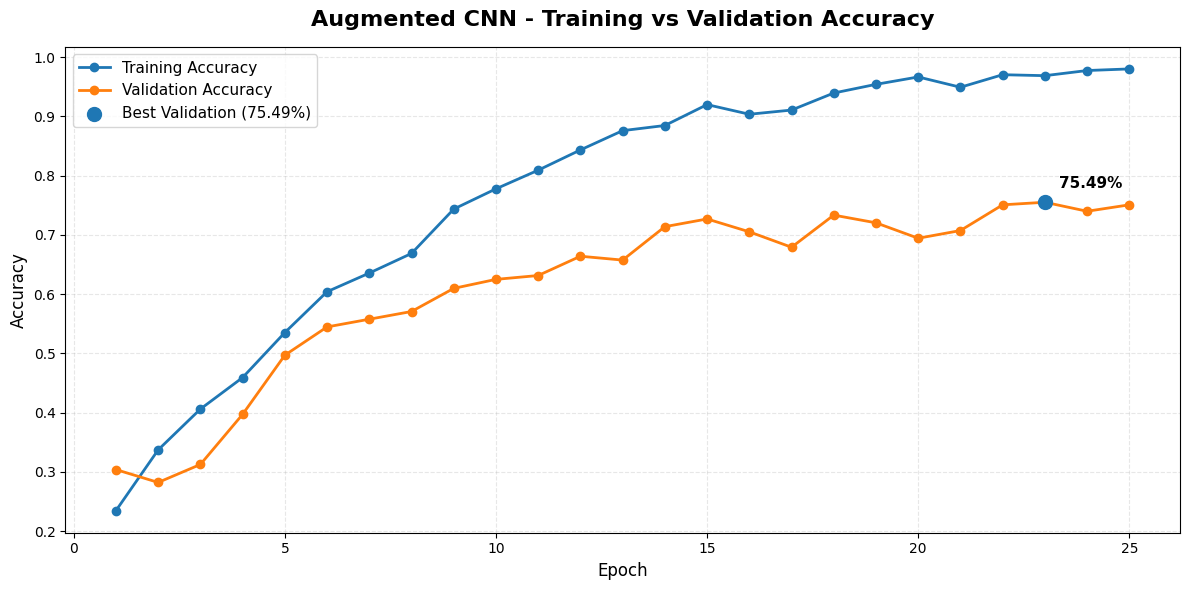

Best Epoch: 23
Best Validation Accuracy: 75.49%


In [ ]:
import matplotlib.pyplot as plt

# Get accuracy values
train_accuracy = history_augmented.history['accuracy']
val_accuracy = history_augmented.history['val_accuracy']

# Epoch numbers
epochs = range(1, len(train_accuracy) + 1)

# Create graph
plt.figure(figsize=(12, 6))

plt.plot(
    epochs,
    train_accuracy,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_accuracy,
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

# Highlight best validation accuracy
best_epoch = np.argmax(val_accuracy) + 1
best_val_accuracy = max(val_accuracy)

plt.scatter(
    best_epoch,
    best_val_accuracy,
    s=100,
    zorder=5,
    label=f'Best Validation ({best_val_accuracy * 100:.2f}%)'
)

plt.annotate(
    f'{best_val_accuracy * 100:.2f}%',
    (best_epoch, best_val_accuracy),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=11,
    fontweight='bold'
)

plt.title(
    'Augmented CNN - Training vs Validation Accuracy',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Accuracy: {best_val_accuracy * 100:.2f}%")

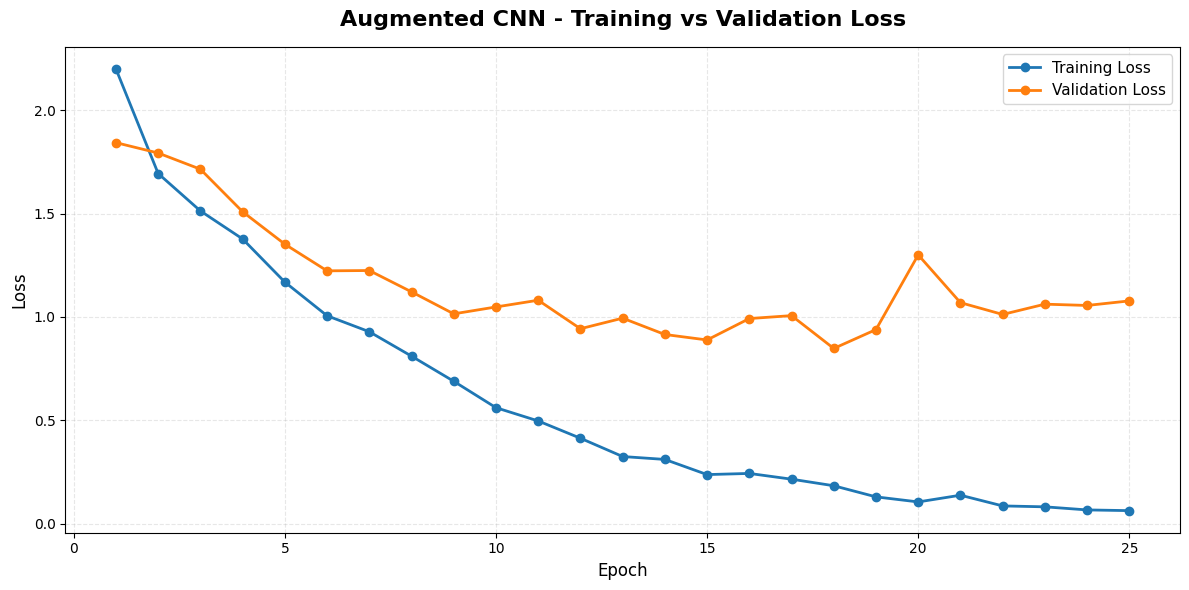

In [ ]:
train_loss = history_augmented.history['loss']
val_loss = history_augmented.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    epochs,
    train_loss,
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    epochs,
    val_loss,
    marker='o',
    linewidth=2,
    label='Validation Loss'
)

plt.title(
    'Augmented CNN - Training vs Validation Loss',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Generate predictions using the final Augmented CNN

y_pred_prob = augmented_model.predict(
    X_test_aug_cnn,
    verbose=1
)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

print("Prediction completed!")
print("Prediction Shape:", y_pred.shape)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
Prediction completed!
Prediction Shape: (288,)


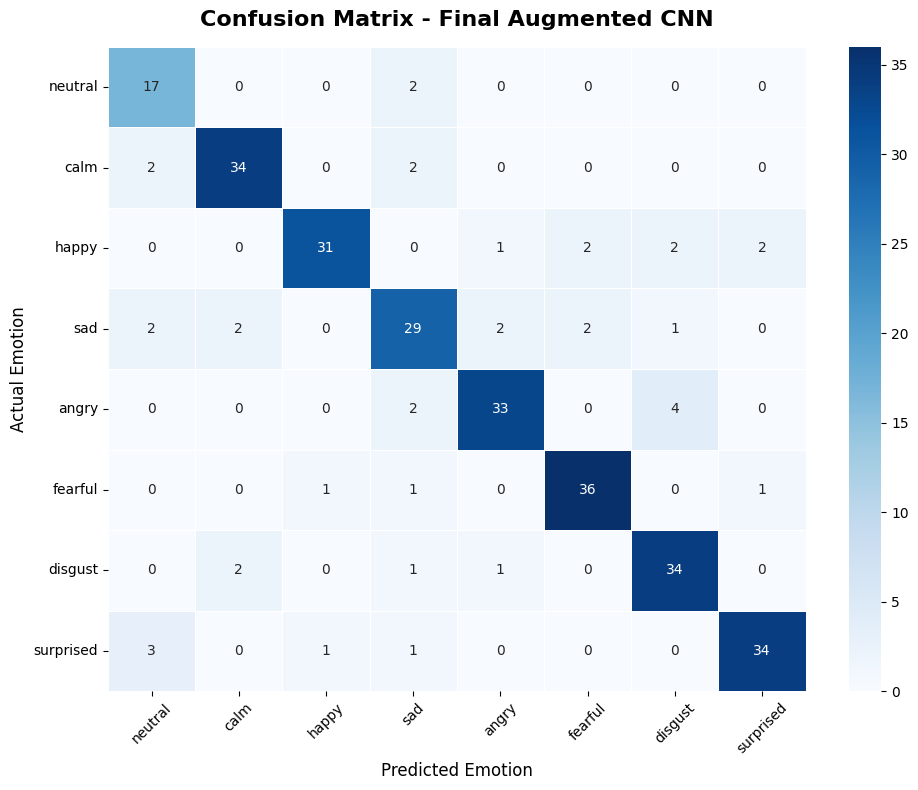

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(
    y_test_final,
    y_pred
)

# Emotion names
emotion_names = [
    'neutral',
    'calm',
    'happy',
    'sad',
    'angry',
    'fearful',
    'disgust',
    'surprised'
]

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    linewidths=0.5
)

plt.title(
    'Confusion Matrix - Final Augmented CNN',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Predicted Emotion',
    fontsize=12
)

plt.ylabel(
    'Actual Emotion',
    fontsize=12
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("\n==============================================")
print("   FINAL AUGMENTED CNN CLASSIFICATION REPORT")
print("==============================================")

print(
    classification_report(
        y_test_final,
        y_pred,
        target_names=emotion_names,
        digits=4
    )
)


   FINAL AUGMENTED CNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

     neutral     0.7083    0.8947    0.7907        19
        calm     0.8947    0.8947    0.8947        38
       happy     0.9394    0.8158    0.8732        38
         sad     0.7632    0.7632    0.7632        38
       angry     0.8919    0.8462    0.8684        39
     fearful     0.9000    0.9231    0.9114        39
     disgust     0.8293    0.8947    0.8608        38
   surprised     0.9189    0.8718    0.8947        39

    accuracy                         0.8611       288
   macro avg     0.8557    0.8630    0.8571       288
weighted avg     0.8659    0.8611    0.8619       288



In [ ]:
# Save the final Augmented CNN model

final_model_path = (
    '/content/drive/MyDrive/Emotion_Recognition/'
    'RAVDESS/final_emotion_cnn_86_11.keras'
)

augmented_model.save(final_model_path)

print("========================================")
print("       FINAL MODEL SAVED")
print("========================================")
print("Model Path:")
print(final_model_path)
print("\nFinal Augmented CNN saved successfully!")

       FINAL MODEL SAVED
Model Path:
/content/drive/MyDrive/Emotion_Recognition/RAVDESS/final_emotion_cnn_86_11.keras

Final Augmented CNN saved successfully!


In [ ]:
import json

emotion_names = [
    'neutral',
    'calm',
    'happy',
    'sad',
    'angry',
    'fearful',
    'disgust',
    'surprised'
]

labels_path = (
    '/content/drive/MyDrive/Emotion_Recognition/'
    'RAVDESS/emotion_labels.json'
)

with open(labels_path, 'w') as f:
    json.dump(emotion_names, f)

print("Emotion labels saved successfully!")

Emotion labels saved successfully!


In [ ]:
import tensorflow as tf
import json

# Load final trained model
final_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/final_emotion_cnn_86_11.keras'
)

# Load emotion labels
with open(
    '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/emotion_labels.json',
    'r'
) as f:
    emotion_names = json.load(f)

print("Final model loaded successfully!")
print("Emotion Classes:", emotion_names)

Final model loaded successfully!
Emotion Classes: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


In [ ]:
test_audio_path = (
    '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/'
    'speech/Ravdess/audio_speech_actors_01-24/'
    'Actor_01/03-01-01-01-01-01-01.wav'
)

print("Selected Audio:")
print(test_audio_path)

Selected Audio:
/content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24/Actor_01/03-01-01-01-01-01-01.wav


In [ ]:
import librosa
import numpy as np

# Load audio
audio, sr = librosa.load(
    test_audio_path,
    sr=22050
)

# Extract MFCC
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

# Make exactly 200 time frames
if mfcc.shape[1] < 200:

    pad_width = 200 - mfcc.shape[1]

    mfcc = np.pad(
        mfcc,
        ((0, 0), (0, pad_width)),
        mode='constant'
    )

else:
    mfcc = mfcc[:, :200]

# CNN input shape
cnn_input = mfcc[np.newaxis, ..., np.newaxis]

print("MFCC Shape:", mfcc.shape)
print("CNN Input Shape:", cnn_input.shape)

# Prediction
prediction = final_model.predict(
    cnn_input,
    verbose=0
)

predicted_index = np.argmax(prediction[0])
predicted_emotion = emotion_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("\n====================================")
print("       EMOTION PREDICTION")
print("====================================")
print("Predicted Emotion :", predicted_emotion)
print(f"Confidence        : {confidence:.2f}%")
print("====================================")

MFCC Shape: (40, 200)
CNN Input Shape: (1, 40, 200, 1)

       EMOTION PREDICTION
Predicted Emotion : neutral
Confidence        : 91.18%


In [ ]:
import librosa
import numpy as np

def predict_emotion(audio_path):

    # Load audio
    audio, sr = librosa.load(
        audio_path,
        sr=22050
    )

    # Extract MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # Make exactly 200 time frames
    if mfcc.shape[1] < 200:

        pad_width = 200 - mfcc.shape[1]

        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, pad_width)),
            mode='constant'
        )

    else:
        mfcc = mfcc[:, :200]

    # Add batch and channel dimensions
    cnn_input = mfcc[np.newaxis, ..., np.newaxis]

    # Predict emotion
    prediction = final_model.predict(
        cnn_input,
        verbose=0
    )

    predicted_index = np.argmax(prediction[0])
    predicted_emotion = emotion_names[predicted_index]

    confidence = prediction[0][predicted_index] * 100

    # Display result
    print("\n========================================")
    print("         SPEECH EMOTION RESULT")
    print("========================================")
    print("Audio File :", audio_path)
    print("Predicted Emotion :", predicted_emotion)
    print(f"Confidence        : {confidence:.2f}%")
    print("========================================")

    return predicted_emotion, confidence

In [ ]:
test_audio_path = (
    '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/'
    'speech/Ravdess/audio_speech_actors_01-24/'
    'Actor_01/03-01-01-01-01-01-01.wav'
)

emotion, confidence = predict_emotion(test_audio_path)


         SPEECH EMOTION RESULT
Audio File : /content/drive/MyDrive/Emotion_Recognition/RAVDESS/speech/Ravdess/audio_speech_actors_01-24/Actor_01/03-01-01-01-01-01-01.wav
Predicted Emotion : neutral
Confidence        : 91.18%


In [ ]:
import os
import pandas as pd
import librosa
import numpy as np

# Dataset path
dataset_path = (
    '/content/drive/MyDrive/Emotion_Recognition/RAVDESS/'
    'speech/Ravdess/audio_speech_actors_01-24'
)

# Store results
results = []

# Process all audio files
for actor in sorted(os.listdir(dataset_path)):

    actor_path = os.path.join(dataset_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file_name in sorted(os.listdir(actor_path)):

        if not file_name.lower().endswith('.wav'):
            continue

        file_path = os.path.join(actor_path, file_name)

        # Load audio
        audio, sr = librosa.load(
            file_path,
            sr=22050
        )

        # Extract MFCC
        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=40
        )

        # Make exactly 200 frames
        if mfcc.shape[1] < 200:

            pad_width = 200 - mfcc.shape[1]

            mfcc = np.pad(
                mfcc,
                ((0, 0), (0, pad_width)),
                mode='constant'
            )

        else:
            mfcc = mfcc[:, :200]

        # CNN input
        cnn_input = mfcc[np.newaxis, ..., np.newaxis]

        # Prediction
        prediction = final_model.predict(
            cnn_input,
            verbose=0
        )

        predicted_index = np.argmax(prediction[0])

        predicted_emotion = emotion_names[predicted_index]

        confidence = prediction[0][predicted_index] * 100

        # Actual emotion from RAVDESS filename
        emotion_code = int(file_name.split('-')[2])

        actual_emotion = emotion_names[emotion_code - 1]

        # Check prediction
        correct = actual_emotion == predicted_emotion

        results.append([
            file_name,
            actual_emotion,
            predicted_emotion,
            confidence,
            correct
        ])

# Create DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        'Audio File',
        'Actual Emotion',
        'Predicted Emotion',
        'Confidence (%)',
        'Correct'
    ]
)

print("========================================")
print("      MULTIPLE AUDIO TEST RESULTS")
print("========================================")

print("Total Audio Files Tested:", len(results_df))

print("\nFirst 10 Results:")
display(results_df.head(10))

      MULTIPLE AUDIO TEST RESULTS
Total Audio Files Tested: 1440

First 10 Results:


,Audio File,Actual Emotion,Predicted Emotion,Confidence (%),Correct
0,03-01-01-01-01-01-01.wav,neutral,neutral,91.176033,True
1,03-01-01-01-01-02-01.wav,neutral,neutral,77.902412,True
2,03-01-01-01-02-01-01.wav,neutral,neutral,94.027924,True
3,03-01-01-01-02-02-01.wav,neutral,neutral,97.260132,True
4,03-01-02-01-01-01-01.wav,calm,calm,97.601692,True
5,03-01-02-01-01-02-01.wav,calm,calm,99.999550,True
6,03-01-02-01-02-01-01.wav,calm,calm,99.997581,True
7,03-01-02-01-02-02-01.wav,calm,calm,99.990868,True
8,03-01-02-02-01-01-01.wav,calm,calm,99.981720,True
9,03-01-02-02-01-02-01.wav,calm,calm,99.999954,True


In [ ]:
# Calculate accuracy on all 1440 audio files

overall_accuracy = results_df['Correct'].mean() * 100

print("\n========================================")
print("       MULTIPLE AUDIO ACCURACY")
print("========================================")
print(f"Total Files Tested : {len(results_df)}")
print(f"Correct Predictions: {results_df['Correct'].sum()}")
print(f"Incorrect Predictions: {(~results_df['Correct']).sum()}")
print(f"Overall Accuracy   : {overall_accuracy:.2f}%")
print("========================================")


       MULTIPLE AUDIO ACCURACY
Total Files Tested : 1440
Correct Predictions: 1333
Incorrect Predictions: 107
Overall Accuracy   : 92.57%


In [ ]:
# Emotion-wise accuracy

emotion_accuracy = (
    results_df
    .groupby('Actual Emotion')['Correct']
    .mean()
    .mul(100)
    .round(2)
)

print("\n========================================")
print("       EMOTION-WISE ACCURACY")
print("========================================")

for emotion, accuracy in emotion_accuracy.items():
    print(f"{emotion.capitalize():12s}: {accuracy:.2f}%")

print("========================================")


       EMOTION-WISE ACCURACY
Angry       : 95.31%
Calm        : 96.35%
Disgust     : 92.71%
Fearful     : 88.02%
Happy       : 90.62%
Neutral     : 90.62%
Sad         : 89.58%
Surprised   : 96.35%


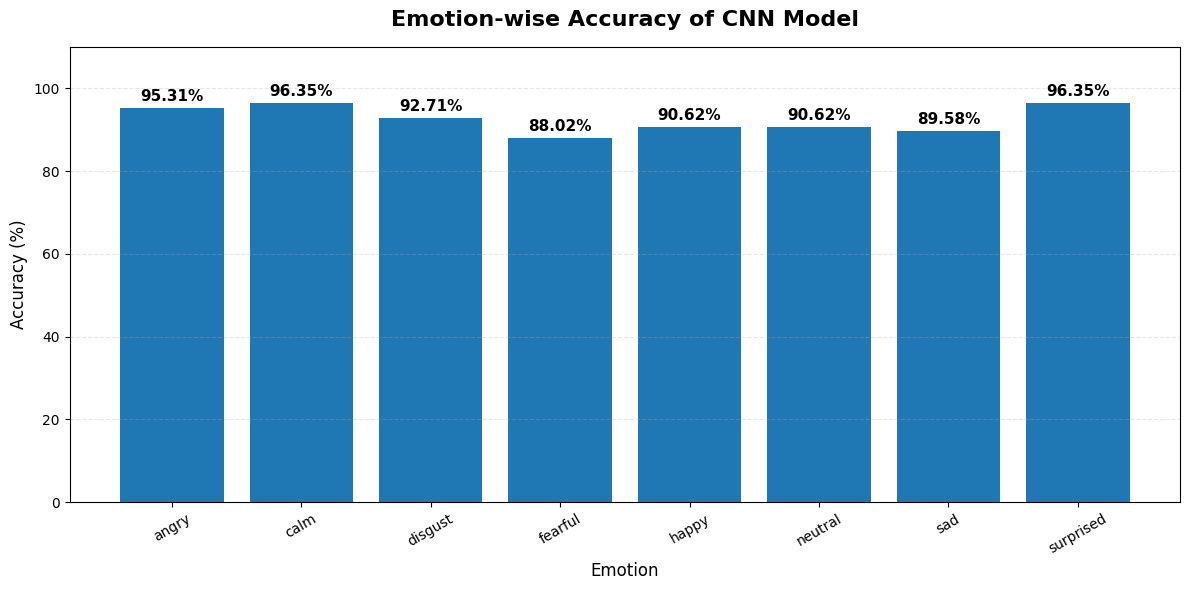

In [ ]:
import matplotlib.pyplot as plt

# Emotion names and accuracies
emotions = emotion_accuracy.index.tolist()
accuracies = emotion_accuracy.values.tolist()

plt.figure(figsize=(12, 6))

bars = plt.bar(
    emotions,
    accuracies
)

# Add accuracy values above bars
for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Emotion-wise Accuracy of CNN Model',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Emotion',
    fontsize=12
)

plt.ylabel(
    'Accuracy (%)',
    fontsize=12
)

plt.ylim(0, 110)
plt.xticks(rotation=30)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step


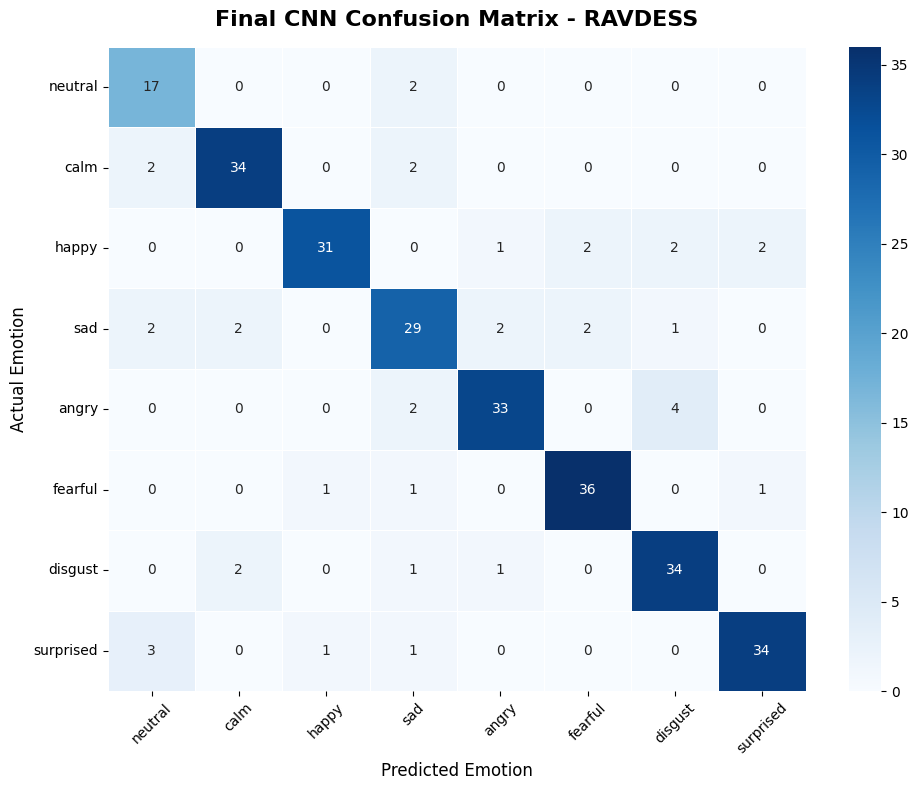

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate predictions on official test set
y_test_pred_prob = augmented_model.predict(
    X_test_aug_cnn,
    verbose=1
)

y_test_pred = np.argmax(y_test_pred_prob, axis=1)

# Confusion Matrix
final_cm = confusion_matrix(
    y_test_final,
    y_test_pred
)

# Emotion labels
emotion_names = [
    'neutral',
    'calm',
    'happy',
    'sad',
    'angry',
    'fearful',
    'disgust',
    'surprised'
]

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    linewidths=0.5,
    cbar=True
)

plt.title(
    'Final CNN Confusion Matrix - RAVDESS',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Predicted Emotion',
    fontsize=12
)

plt.ylabel(
    'Actual Emotion',
    fontsize=12
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

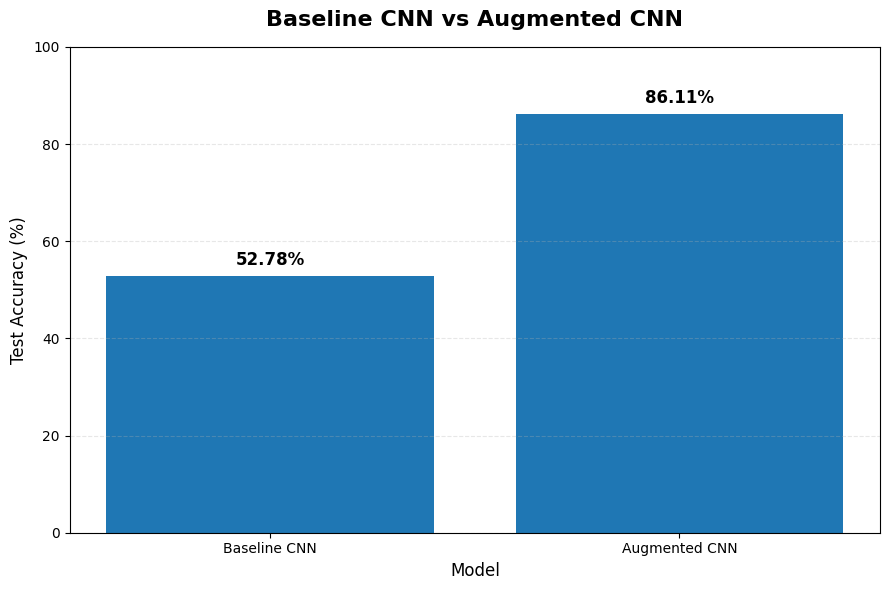

In [ ]:
import matplotlib.pyplot as plt

# Model accuracies
models = [
    'Baseline CNN',
    'Augmented CNN'
]

accuracies = [
    52.78,
    86.11
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    models,
    accuracies
)

# Accuracy values on bars
for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    'Baseline CNN vs Augmented CNN',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Model',
    fontsize=12
)

plt.ylabel(
    'Test Accuracy (%)',
    fontsize=12
)

plt.ylim(0, 100)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

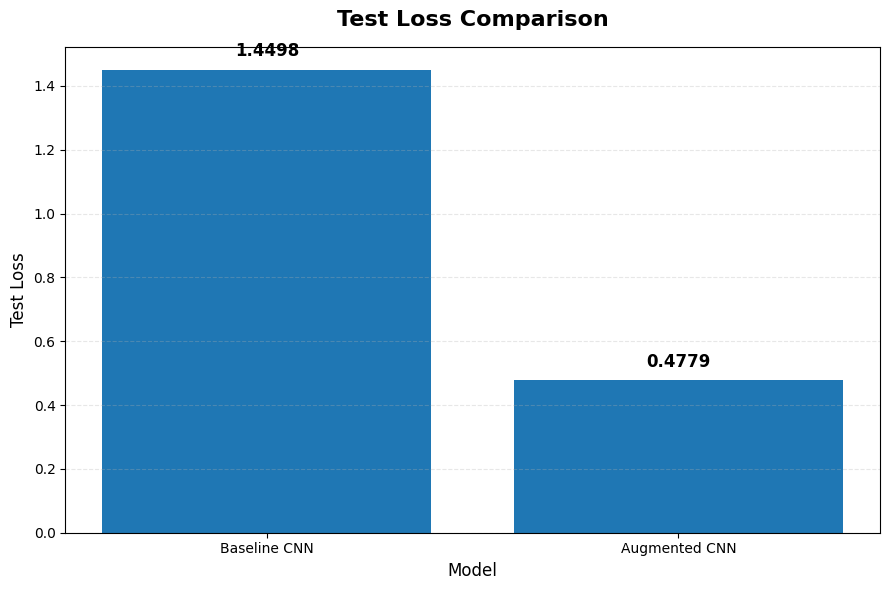

In [ ]:
import matplotlib.pyplot as plt

models = [
    'Baseline CNN',
    'Augmented CNN'
]

losses = [
    1.4498,
    0.4779
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    models,
    losses
)

for bar, value in zip(bars, losses):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f'{value:.4f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    'Test Loss Comparison',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Model',
    fontsize=12
)

plt.ylabel(
    'Test Loss',
    fontsize=12
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("       EMOTION RECOGNITION FROM SPEECH")
print("             FINAL PROJECT RESULTS")
print("=" * 60)

print("\nDataset")
print("-" * 60)
print("Dataset       : RAVDESS")
print("Total Audio   : 1440")
print("Emotion Classes: 8")

print("\nFeature Extraction")
print("-" * 60)
print("Feature       : MFCC")
print("MFCC Features : 40")
print("Time Frames   : 200")

print("\nData Augmentation")
print("-" * 60)
print("Original Samples : 1440")
print("Augmented Samples: 2880")

print("\nModel")
print("-" * 60)
print("Architecture : CNN")
print("Input Shape  : (40, 200, 1)")

print("\nModel Comparison")
print("-" * 60)
print("Baseline CNN Accuracy  : 52.78%")
print("Augmented CNN Accuracy : 86.11%")
print("Improvement            : 33.33 percentage points")

print("\nFinal Test Performance")
print("-" * 60)
print("Test Accuracy : 86.11%")
print("Macro F1      : 85.71%")
print("Weighted F1   : 86.19%")
print("Test Loss     : 0.4779")

print("\nAdditional Analysis")
print("-" * 60)
print("All Audio Files Tested : 1440")
print("Correct Predictions    : 1333")
print("Incorrect Predictions  : 107")
print("Overall Accuracy       : 92.57%")

print("\nFinal Model")
print("-" * 60)
print("final_emotion_cnn_86_11.keras")

print("=" * 60)
print("          PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

       EMOTION RECOGNITION FROM SPEECH
             FINAL PROJECT RESULTS

Dataset
------------------------------------------------------------
Dataset       : RAVDESS
Total Audio   : 1440
Emotion Classes: 8

Feature Extraction
------------------------------------------------------------
Feature       : MFCC
MFCC Features : 40
Time Frames   : 200

Data Augmentation
------------------------------------------------------------
Original Samples : 1440
Augmented Samples: 2880

Model
------------------------------------------------------------
Architecture : CNN
Input Shape  : (40, 200, 1)

Model Comparison
------------------------------------------------------------
Baseline CNN Accuracy  : 52.78%
Augmented CNN Accuracy : 86.11%
Improvement            : 33.33 percentage points

Final Test Performance
------------------------------------------------------------
Test Accuracy : 86.11%
Macro F1      : 85.71%
Weighted F1   : 86.19%
Test Loss     : 0.4779

Additional Analysis
------------------